# Figure 2: Tissue-specific pathway retention

This notebook regenerates a tissue-specific pathway-retention heatmap from the local **ExposoGraph** package.

Inputs used here:

- `ExposoGraph.build_reference_graph()` for the bundled reference knowledge graph.
- `ExposoGraph.get_tissue_expression()` for HPA/GTEx-derived tissue expression in nTPM.
- Class-to-carcinogen mappings defined below from the reference graph's `edge.carcinogen` labels.

The default calculation treats a class edge as retained in a tissue when every enzyme/gene endpoint on that edge has tissue expression greater than or equal to `TPM_THRESHOLD`. Non-enzyme context nodes are retained. This matches the figure title wording (`TPM expression threshold`) and avoids using the normalized tissue-weight threshold used by some ExposoGraph API helpers.

Note: the current bundled reference graph does not contain explicit Aristolochic-acid pathway edges. That row is kept as `n/a` so the absence is visible rather than silently imputed.


In [48]:
from __future__ import annotations

import csv
import sys
from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Make the notebook robust whether it is launched from the repo root or from Figures_Notebook/.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "ExposoGraph").is_dir() and (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the ExposoGraph repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

OUTPUT_DIR = REPO_ROOT / "Figures_Notebook" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TPM_THRESHOLD = 1.5
TISSUES = ["Liver", "Lung", "Prostate", "Bladder", "Colon", "Breast", "Kidney", "Esophagus"]

print(f"Repository root: {REPO_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Repository root: /Users/greghamilton/Documents/GitHub/ExposoGraph2
Output directory: /Users/greghamilton/Documents/GitHub/ExposoGraph2/Figures_Notebook/output


In [49]:
from ExposoGraph import build_reference_graph, get_tissue_expression

graph = build_reference_graph()
nodes = [node.model_dump(mode="json") for node in graph.nodes]
edges = [edge.model_dump(mode="json") for edge in graph.edges]

In [50]:
node_carc = [node for node in nodes if node['type'] =='Carcinogen']

In [51]:
result = {}
for i in node_carc:
    carc = i['group']
    if carc in result.keys():
        result[carc].append(i['id'])
    else:
        result[carc] = [i['id']] 



In [52]:
CLASS_CARCINOGENS = result

## Class definitions

The rows below aggregate ExposoGraph `edge.carcinogen` labels into manuscript-level carcinogen classes. Edit this mapping if the manuscript figure should use a narrower or broader class definition.


## Compute class-specific retention

For each class and tissue, the denominator is the number of reference graph edges whose `carcinogen` label belongs to that class. The numerator is the number of those edges retained after applying the nTPM threshold to enzyme/gene endpoints.


### Build expression by tissue

In [ ]:
enzyme_nodes = [i for i in nodes if i['type']=='Enzyme']
expression_by_tissue = {}
for enzyme in enzyme_nodes:
    print(enzyme['id'])
    print(enzyme.keys())
    if 'tissue_weights' in enzyme.keys():
        tissue_weights = enzyme['tissue_weights']
        print(tissue_weights)
        for tissue in tissue_weights.keys():
            if tissue in expression_by_tissue.keys():
                expression_by_tissue[tissue][enzyme['id']] = enzyme['tissue_weights'][tissue]
            else:
                expression_by_tissue[tissue] = {enzyme['id']:enzyme['tissue_weights'][tissue]} 


CYP1A1
{'Liver': 1.0, 'Lung': 0.2487, 'Prostate': 0.0151, 'Bladder': 0.201, 'Colon': 0.0477, 'Breast': 0.3518, 'Kidney': 0.0302, 'Esophagus': 0.0452}
CYP1B1
{'Liver': 0.2404, 'Lung': 0.7596, 'Prostate': 1.0, 'Bladder': 0.2885, 'Colon': 0.1587, 'Breast': 0.8029, 'Kidney': 0.5529, 'Esophagus': 0.1923}
CYP1A2
{'Liver': 1.0, 'Lung': 0.0, 'Prostate': 0.0, 'Bladder': 0.0, 'Colon': 0.0, 'Breast': 0.0, 'Kidney': 0.0, 'Esophagus': 0.0}
CYP2A6
{'Liver': 1.0, 'Lung': 0.0, 'Prostate': 0.0, 'Bladder': 0.0, 'Colon': 0.0, 'Breast': 0.0, 'Kidney': 0.0, 'Esophagus': 0.0}
CYP2A13
{'Liver': 1.0, 'Lung': 0.0526, 'Prostate': 0.0, 'Bladder': 0.0526, 'Colon': 0.0, 'Breast': 0.0, 'Kidney': 0.0, 'Esophagus': 0.0}
CYP2B6
{'Liver': 1.0, 'Lung': 0.0, 'Prostate': 0.0, 'Bladder': 0.0, 'Colon': 0.0, 'Breast': 0.0, 'Kidney': 0.0268, 'Esophagus': 0.0}
CYP2C9
{'Liver': 1.0, 'Lung': 0.0, 'Prostate': 0.0, 'Bladder': 0.0, 'Colon': 0.0, 'Breast': 0.0, 'Kidney': 0.0, 'Esophagus': 0.0}
CYP2C19
{'Liver': 1.0, 'Lung': 0.0, 'Pr

AttributeError: 'NoneType' object has no attribute 'keys'

In [ ]:
node_type_by_id = {node["id"]: node.get("type", "") for node in nodes}
expression_by_tissue = {tissue: get_tissue_expression(tissue) for tissue in TISSUES}

def is_gene_like(node_id: str) -> bool:
    return node_type_by_id.get(node_id) in {"Enzyme", "Gene"}


def edge_retained(edge: dict[str, object], tissue: str, threshold: float = TPM_THRESHOLD) -> bool:
    expression = expression_by_tissue[tissue]
    for endpoint in (str(edge.get("source", "")), str(edge.get("target", ""))):
        if is_gene_like(endpoint) and (float(expression.get(endpoint, 0.0)) < threshold):
            return False
    return True


def class_edges(carcinogens: list[str]) -> list[dict[str, object]]:
    labels = set(carcinogens)
    return [edge for edge in edges if edge.get("carcinogen") in labels]

matrix = np.full((len(CLASS_CARCINOGENS), len(TISSUES)), np.nan, dtype=float)
edge_counts: dict[str, int] = {}
retained_counts: dict[tuple[str, str], int] = {}

for row_idx, (class_name, carcinogens) in enumerate(CLASS_CARCINOGENS.items()):
    selected_edges = class_edges(carcinogens)
    edge_counts[class_name] = len(selected_edges)
    if not selected_edges:
        continue
    for col_idx, tissue in enumerate(TISSUES):
        retained = sum(edge_retained(edge, tissue) for edge in selected_edges)
        retained_counts[(class_name, tissue)] = retained
        matrix[row_idx, col_idx] = 100.0 * retained / len(selected_edges)

print(f"Reference graph: {len(nodes)} nodes / {len(edges)} edges")
for class_name in CLASS_CARCINOGENS:
    print(f"{class_name:24s} {edge_counts[class_name]:3d} class edges")

Reference graph: 231 nodes / 335 edges
PAH                       13 class edges
HCA                        8 class edges
Aromatic_Amine             6 class edges
Nitrosamine               13 class edges
Mycotoxin                  5 class edges
Estrogen                   7 class edges
Androgen                  12 class edges
Benzene                    3 class edges
Vinyl Chloride             4 class edges
Alkylating                35 class edges
Heavy_Metal               56 class edges
Aldehyde                  33 class edges
Dioxin                    10 class edges
PCB                       10 class edges
Chlorinated_Solvent       11 class edges
Alcohol                    7 class edges
Organochlorine            10 class edges


In [57]:
expression_by_tissue

{'Liver': {'ABCB1': 6.5,
  'ABCC2': 88.0,
  'ABCG2': 7.9,
  'ADH1B': 1599.6,
  'ADH1C': 703.3,
  'ADH5': 164.5,
  'AHR': 14.3,
  'AHRR': 0.5,
  'AKR1C2': 448.7,
  'AKR1C3': 285.4,
  'ALDH2': 454.8,
  'ARNT': 24.1,
  'AS3MT': 34.4,
  'CCBL1': 11.8,
  'COMT': 268.0,
  'CYP17A1': 6.5,
  'CYP19A1': 0.0,
  'CYP1A1': 39.8,
  'CYP1A2': 248.8,
  'CYP1B1': 5.0,
  'CYP2A13': 1.9,
  'CYP2A6': 906.0,
  'CYP2B6': 306.1,
  'CYP2C19': 58.9,
  'CYP2C9': 675.4,
  'CYP2D6': 386.2,
  'CYP2E1': 5442.1,
  'CYP2F1': 0.0,
  'CYP3A4': 521.7,
  'CYP3A5': 319.4,
  'EPHX1': 1202.7,
  'ERCC2': 6.9,
  'FANCD2': 0.3,
  'GSTM1': 532.3,
  'GSTO1': 490.0,
  'GSTO2': 1.4,
  'GSTP1': 62.2,
  'HLA_DPB1': 36.5,
  'HSD3B2': 1.0,
  'MGMT': 125.9,
  'MLH1': 10.7,
  'MSH2': 3.6,
  'MT1A': 400.5,
  'MT2A': 15847.5,
  'NAT1': 9.8,
  'NAT2': 70.9,
  'NQO1': 4.9,
  'OGG1': 17.9,
  'PARP1': 26.7,
  'SLC11A1': 5.3,
  'SRD5A1': 16.7,
  'SRD5A2': 22.1,
  'SULT1A1': 179.8,
  'UGT1A1': 344.8,
  'UGT2B15': 124.3,
  'UGT2B17': 19.8,
  'U

## Render heatmap

The color scale is fixed to 40-100% to match the draft Figure 2 visual range. Cells without class edges are shown in light gray and annotated as `n/a`.


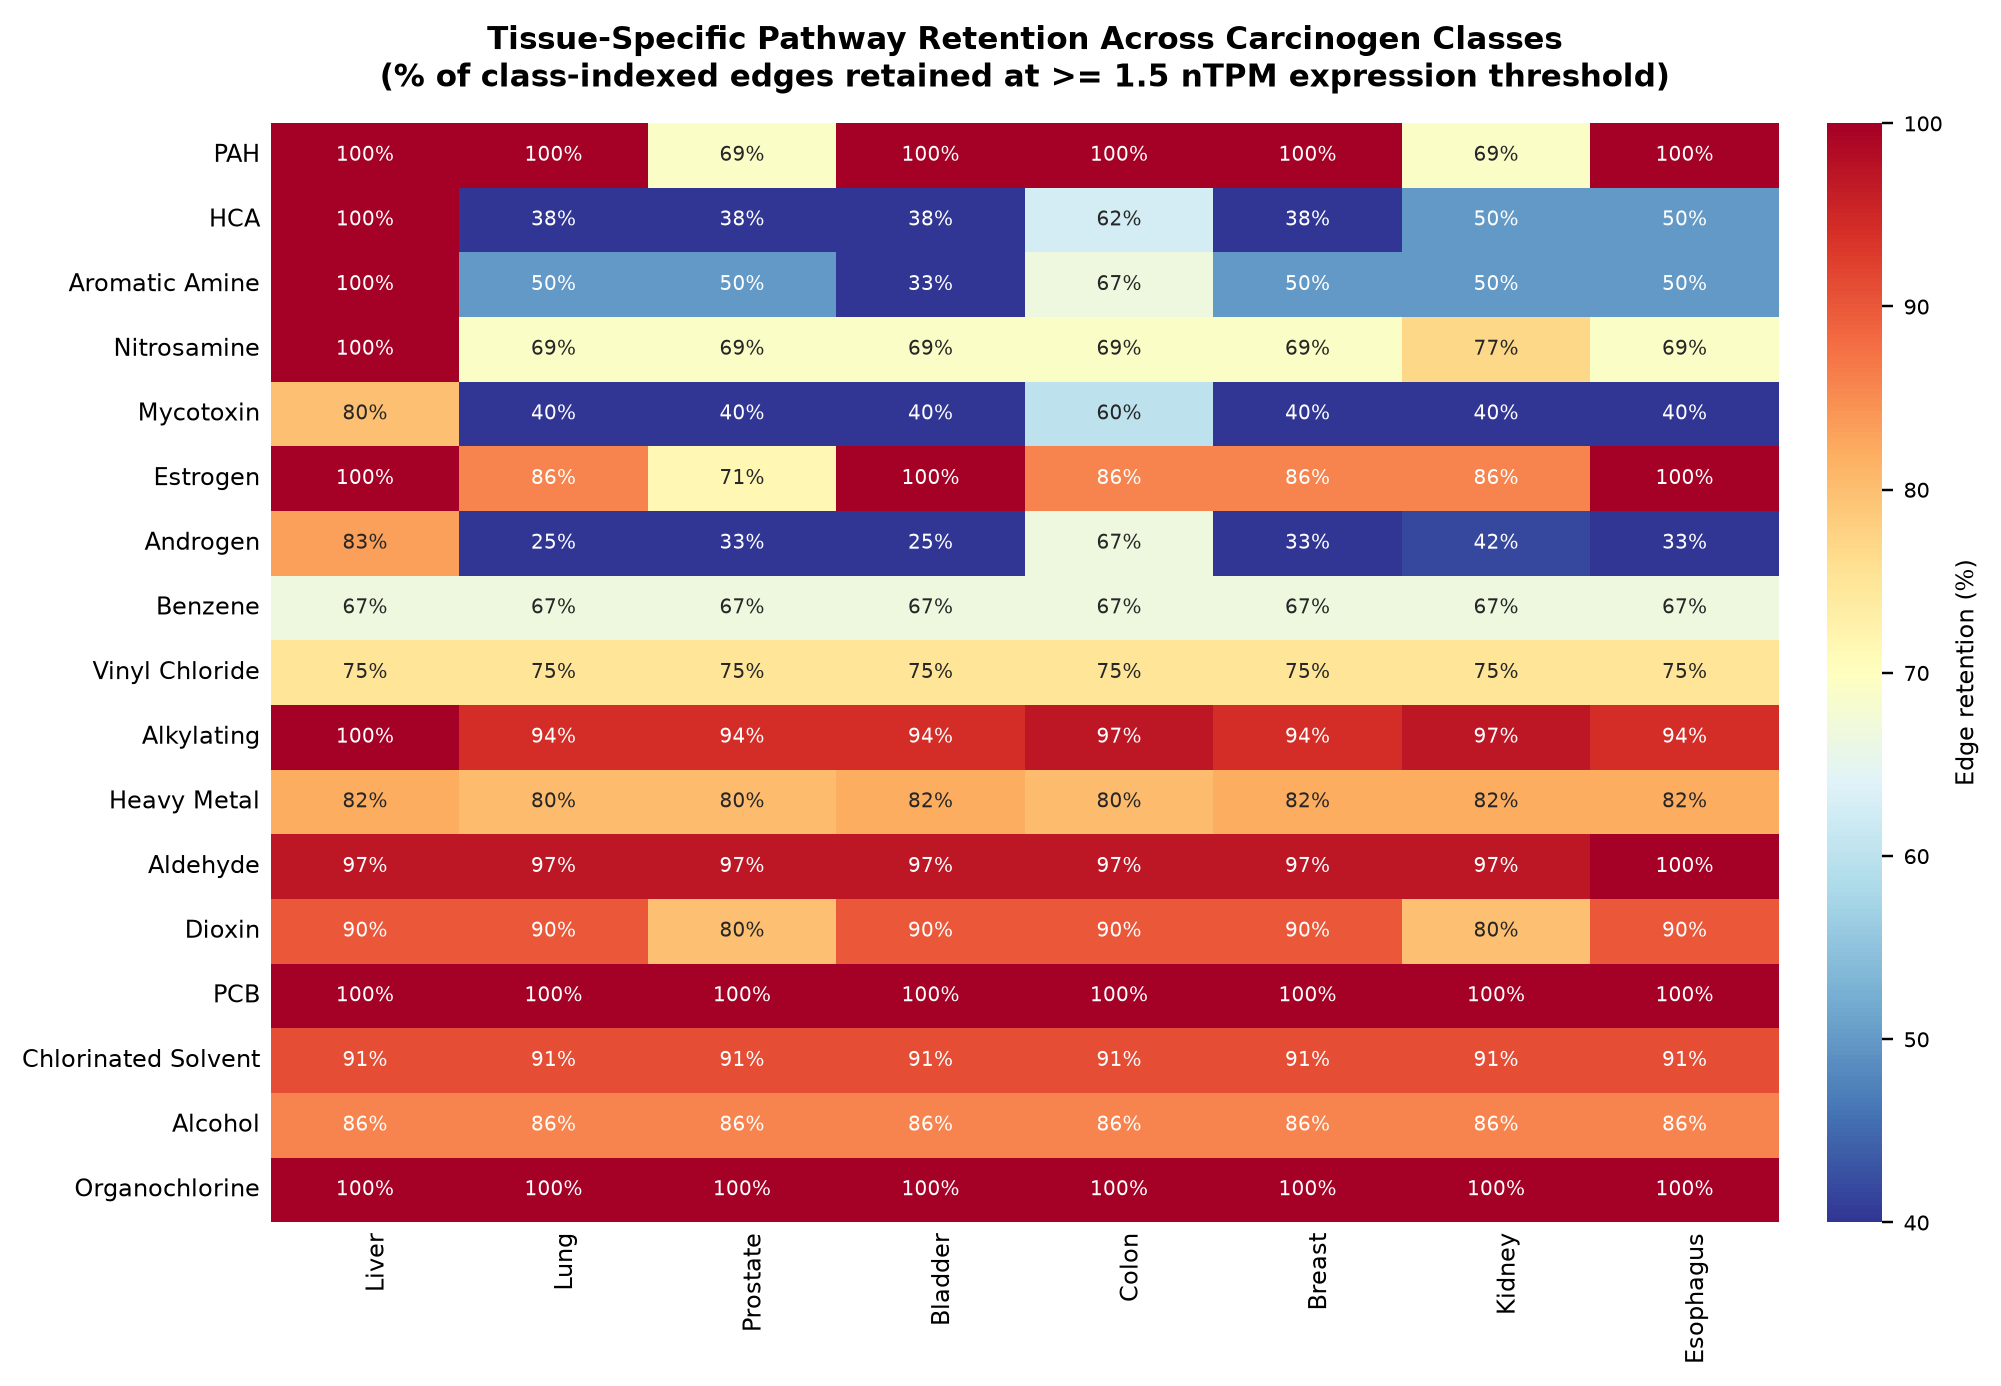

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

row_labels = list(CLASS_CARCINOGENS.keys())
row_labels = [name.replace("_", " ") for name in CLASS_CARCINOGENS.keys()]

# Generate text annotation matrix matching your requirements
annot_matrix = np.where(np.isnan(matrix), "n/a", np.vectorize(lambda x: f"{x:.0f}%")(matrix))

# Set up figure
fig, ax = plt.subplots(figsize=(9.2, 6.4), dpi=220)

# Generate Seaborn heatmap
sns.heatmap(
    matrix,
    mask=np.isnan(matrix),
    cmap="RdYlBu_r",
    vmin=40,
    vmax=100,
    annot=annot_matrix,
    fmt="",
    annot_kws={"fontsize": 6.6},
    xticklabels=TISSUES,
    yticklabels=row_labels,
    cbar_kws={"fraction": 0.035, "pad": 0.03, "label": "Edge retention (%)"},
    ax=ax,
)

# # Apply dynamic text colors to heatmap annotations
# for text, color in zip(ax.texts, text_colors.ravel()):
#     text.set_color(color)

# Style ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
ax.tick_params(axis="both", length=0)

# Style colorbar labels
cbar = ax.collections[0].colorbar
cbar.set_label("Edge retention (%)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

# Set title and footer text
title = (
    "Tissue-Specific Pathway Retention Across Carcinogen Classes\n"
    f"(% of class-indexed edges retained at >= {TPM_THRESHOLD:g} nTPM expression threshold)"
)
ax.set_title(title, fontsize=10, weight="bold", pad=12)



fig.tight_layout()#rect=(0, 0.04, 1, 1))
plt.show()


<!-- ## Sanity checks

These checks make figure regeneration fail loudly if the reference graph or tissue data contract changes in a way that affects the manuscript figure. -->


In [6]:
assert len(nodes) == 214, f"Expected 214 reference nodes, found {len(nodes)}"
assert len(edges) == 321, f"Expected 321 reference edges, found {len(edges)}"
assert TISSUES == ["Liver", "Lung", "Prostate", "Bladder", "Colon", "Breast", "Kidney", "Esophagus"]
assert edge_counts["PAHs"] > 0
assert edge_counts["Heavy metals"] > 0

missing_rows = [class_name for class_name, count in edge_counts.items() if count == 0]
print("Rows without explicit reference-graph edges:", missing_rows or "none")

Rows without explicit reference-graph edges: ['Aristolochic acid']
